# SEÇÃO 1: TRATAMENTO DE DADOS FALTANTES

In [1]:
import pandas as pd
import seaborn as sns

In [3]:
# Carregando o dataset Titanic
df_titanic = sns.load_dataset('titanic')

In [4]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df_titanic.shape

(891, 15)

In [6]:
print("\nVerificando dados faltantes no dataset original:")
print(df_titanic.isnull().sum())


Verificando dados faltantes no dataset original:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


# --- ESTRATÉGIAS DE TRATAMENTO ---

In [7]:
df_titanic['age']

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [8]:
# 1. Imputação Numérica: Preenchendo a coluna 'age' com a mediana
# A mediana é mais robusta a outliers do que a média.
median_age = df_titanic['age'].median()
df_titanic.fillna({'age': median_age}, inplace=True)
print(f"\nValores faltantes em 'age' preenchidos com a mediana ({median_age}).")


Valores faltantes em 'age' preenchidos com a mediana (28.0).


In [9]:
df_titanic['age']

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [10]:
df_titanic['embark_town'].mode()

,embark_town
0,Southampton


In [11]:
# 2. Imputação Categórica: Preenchendo 'embark_town' e 'embarked' com a moda
# A moda é o valor mais frequente na coluna.
mode_town = df_titanic['embark_town'].mode()[0]
df_titanic.fillna({'embark_town': mode_town}, inplace=True)

print(f"Valores faltantes em 'embark_town' preenchidos com a moda ({mode_town}).")

mode_embarked = df_titanic['embarked'].mode()[0]
df_titanic.fillna({'embarked': mode_embarked}, inplace=True)

print(f"Valores faltantes em 'embarked' preenchidos com a moda ({mode_embarked}).")

Valores faltantes em 'embark_town' preenchidos com a moda (Southampton).
Valores faltantes em 'embarked' preenchidos com a moda (S).


In [12]:
# 3. Remoção de Coluna: A coluna 'deck' tem muitos valores faltantes (>75%)
# É uma boa prática removê-la para não adicionar ruído ao modelo.
df_titanic.drop('deck', axis=1, inplace=True) # axis=1 => colunas, axis=0 => linhas
print("Coluna 'deck' removida por excesso de dados faltantes.")

Coluna 'deck' removida por excesso de dados faltantes.


In [13]:
df_titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [14]:
# --- VERIFICAÇÃO FINAL ---
print("\nVerificação de dados faltantes após o tratamento:")
print(df_titanic.isnull().sum())


Verificação de dados faltantes após o tratamento:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [15]:
print("\nDataset Tratado - 5 primeiras linhas:")
df_titanic.head()


Dataset Tratado - 5 primeiras linhas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


# SEÇÃO 2: CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
# Usaremos o dataframe 'df_titanic' limpo da seção anterior.
df_encoded = df_titanic.copy()

print("Colunas categóricas originais: 'sex', 'embarked'")
print(df_encoded[['sex', 'embarked']].head())

Colunas categóricas originais: 'sex', 'embarked'
      sex embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S


In [18]:
df_encoded['sex'].unique()

array(['male', 'female'], dtype=object)

In [19]:
df_encoded['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [20]:
# --- TÉCNICAS DE ENCODING ---

# 1. One-Hot Encoding: Ideal para variáveis nominais (sem ordem).
# Cria novas colunas binárias para cada categoria.
# Usaremos a função get_dummies do Pandas, que é muito prática.
df_encoded = pd.get_dummies(df_encoded, columns=['sex', 'embarked'], drop_first=True)
# 'drop_first=True' remove uma categoria de cada variável para evitar multicolinearidade.
# Ex: se sex_male=0, sabemos que é female.
print("\nDataset após One-Hot Encoding em 'sex' e 'embarked':")
df_encoded.head()


Dataset após One-Hot Encoding em 'sex' e 'embarked':


,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,True,False,True


In [21]:
# 2. Label Encoding: Ideal para variáveis ordinais (com ordem).
# Atribui um número inteiro a cada categoria (ex: 0, 1, 2...).
# Vamos aplicar na coluna 'class' como exemplo.
label_encoder = LabelEncoder()
df_encoded['class_encoded'] = label_encoder.fit_transform(df_encoded['class'])

print("\nColuna 'class' original e após Label Encoding:")
print("\nMapeamento das classes:", {index: label for index, label in enumerate(label_encoder.classes_)})
df_encoded[['class', 'class_encoded']].head()


Coluna 'class' original e após Label Encoding:

Mapeamento das classes: {0: 'First', 1: 'Second', 2: 'Third'}


,class,class_encoded
0,Third,2
1,First,0
2,Third,2
3,First,0
4,Third,2


In [22]:
df_encoded

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,class_encoded
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,True,False,True,2
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,False,False,False,0
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,False,False,True,2
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,False,False,True,0
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,True,False,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,Second,man,True,Southampton,no,True,True,False,True,1
887,1,1,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True,False,False,True,0
888,0,3,28.0,1,2,23.4500,Third,woman,False,Southampton,no,False,False,False,True,2
889,1,1,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True,True,False,False,0


In [23]:
# Remoção de Colunas Irrelevantes
# Colunas como 'who', 'adult_male', 'alive', 'class', 'embarked' são redundantes ou já foram tratadas.
df_encoded.drop(['who', 'adult_male', 'alive', 'class', 'embark_town', 'pclass'], axis=1, inplace=True)
print("Colunas redundantes ou desnecessárias foram removidas.")
df_encoded

Colunas redundantes ou desnecessárias foram removidas.


,survived,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S,class_encoded
0,0,22.0,1,0,7.2500,False,True,False,True,2
1,1,38.0,1,0,71.2833,False,False,False,False,0
2,1,26.0,0,0,7.9250,True,False,False,True,2
3,1,35.0,1,0,53.1000,False,False,False,True,0
4,0,35.0,0,0,8.0500,True,True,False,True,2
...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,0,0,13.0000,True,True,False,True,1
887,1,19.0,0,0,30.0000,True,False,False,True,0
888,0,28.0,1,2,23.4500,False,False,False,True,2
889,1,26.0,0,0,30.0000,True,True,False,False,0


# SEÇÃO 3: DISCRETIZAÇÃO (BINNING)

In [24]:
print("Coluna 'age' original (contínua):")
df_encoded['age'].head()

Coluna 'age' original (contínua):


,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [25]:
s = pd.Series([2, 5, 7, 9, 12, 20])
pd.cut(s, bins=3) # 3 faixas do menor ao maior

,0
0,"(1.982, 8.0]"
1,"(1.982, 8.0]"
2,"(1.982, 8.0]"
3,"(8.0, 14.0]"
4,"(8.0, 14.0]"
5,"(14.0, 20.0]"


In [26]:
pd.cut(s, bins=3, labels=["baixa","média","alta"])

,0
0,baixa
1,baixa
2,baixa
3,média
4,média
5,alta


In [27]:
# --- TÉCNICA DE BINNING ---

# 1. Definir os limites (bins) e os rótulos (labels)
# Limites: 0 a 12 (Criança), 12 a 18 (Adolescente), 18 a 60 (Adulto), 60+ (Idoso)
bins = [0, 12, 18, 60, df_encoded['age'].max()]
labels = ['Criança', 'Adolescente', 'Adulto', 'Idoso']

# 2. Aplicar a discretização com a função cut() do Pandas
df_encoded['faixa_etaria'] = pd.cut(
    df_encoded['age'],
    bins=bins,
    labels=labels,
    right=False # Intervalo fechado à esquerda, ex: [0, 12)
)

print("\nColuna 'faixa_etaria' criada a partir de 'age':")
df_encoded[['age', 'faixa_etaria']].head(10)


Coluna 'faixa_etaria' criada a partir de 'age':


,age,faixa_etaria
0,22.0,Adulto
1,38.0,Adulto
2,26.0,Adulto
3,35.0,Adulto
4,35.0,Adulto
5,28.0,Adulto
6,54.0,Adulto
7,2.0,Criança
8,27.0,Adulto
9,14.0,Adolescente


In [28]:
# Verificando a distribuição nas novas faixas etárias
print("\nContagem de pessoas por faixa etária:")
print(df_encoded['faixa_etaria'].value_counts())


Contagem de pessoas por faixa etária:
faixa_etaria
Adulto         752
Criança         68
Adolescente     45
Idoso           25
Name: count, dtype: int64


# SEÇÃO 4: ESCALONAMENTO DE ATRIBUTOS

In [29]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Carregando o dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [30]:
# Vamos focar em algumas colunas
cols_to_scale = ['MedInc', 'HouseAge', 'AveRooms']
print("Estatísticas Descritivas ANTES do Escalonamento:")
print(df_housing[cols_to_scale].describe())

Estatísticas Descritivas ANTES do Escalonamento:
             MedInc      HouseAge      AveRooms
count  20640.000000  20640.000000  20640.000000
mean       3.870671     28.639486      5.429000
std        1.899822     12.585558      2.474173
min        0.499900      1.000000      0.846154
25%        2.563400     18.000000      4.440716
50%        3.534800     29.000000      5.229129
75%        4.743250     37.000000      6.052381
max       15.000100     52.000000    141.909091


In [31]:
# --- TÉCNICAS DE ESCALONAMENTO ---

# Criando cópias para não alterar o dataframe original
df_normalized = df_housing.copy()
df_standardized = df_housing.copy()

In [32]:
# 1. Normalização (MinMaxScaler): Coloca os dados em uma escala de 0 a 1.
scaler_minmax = MinMaxScaler()
df_normalized[cols_to_scale] = scaler_minmax.fit_transform(df_housing[cols_to_scale])

print("\nEstatísticas Descritivas APÓS Normalização (MinMaxScaler):")
print(df_normalized[cols_to_scale].describe())


Estatísticas Descritivas APÓS Normalização (MinMaxScaler):
             MedInc      HouseAge      AveRooms
count  20640.000000  20640.000000  20640.000000
mean       0.232464      0.541951      0.032488
std        0.131020      0.246776      0.017539
min        0.000000      0.000000      0.000000
25%        0.142308      0.333333      0.025482
50%        0.209301      0.549020      0.031071
75%        0.292641      0.705882      0.036907
max        1.000000      1.000000      1.000000


In [33]:
# 2. Padronização (StandardScaler): Transforma os dados para terem média 0 e desvio padrão 1.
# Útil para algoritmos que assumem uma distribuição gaussiana dos dados.
scaler_standard = StandardScaler()
df_standardized[cols_to_scale] = scaler_standard.fit_transform(df_housing[cols_to_scale])

print("\nEstatísticas Descritivas APÓS Padronização (StandardScaler):")
print(df_standardized[cols_to_scale].describe())


Estatísticas Descritivas APÓS Padronização (StandardScaler):
             MedInc      HouseAge      AveRooms
count  2.064000e+04  2.064000e+04  2.064000e+04
mean   6.609700e-17  5.508083e-18  6.609700e-17
std    1.000024e+00  1.000024e+00  1.000024e+00
min   -1.774299e+00 -2.196180e+00 -1.852319e+00
25%   -6.881186e-01 -8.453931e-01 -3.994496e-01
50%   -1.767951e-01  2.864572e-02 -8.078489e-02
75%    4.593063e-01  6.643103e-01  2.519615e-01
max    5.858286e+00  1.856182e+00  5.516324e+01


# SEÇÃO 5: TRATAMENTO DE OUTLIERS

In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Carregando o dataset Boston Housing
url = '/content/boston.csv'
df_boston = pd.read_csv(url)
df_boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [37]:
# Foco na coluna 'CRIM' (taxa de criminalidade per capita)
print("Descrição da coluna 'CRIM' ANTES do tratamento:")
df_boston['CRIM'].describe()

Descrição da coluna 'CRIM' ANTES do tratamento:


,CRIM
count,506.000000
mean,3.613524
std,8.601545
min,0.006320
25%,0.082045
50%,0.256510
75%,3.677083
max,88.976200


In [44]:
! pip freeze | grep pandas

geopandas==1.1.3
pandas==2.2.2
pandas-datareader==0.10.0
pandas-gbq==0.30.0
pandas-stubs==2.2.2.240909
sklearn-pandas==2.2.0


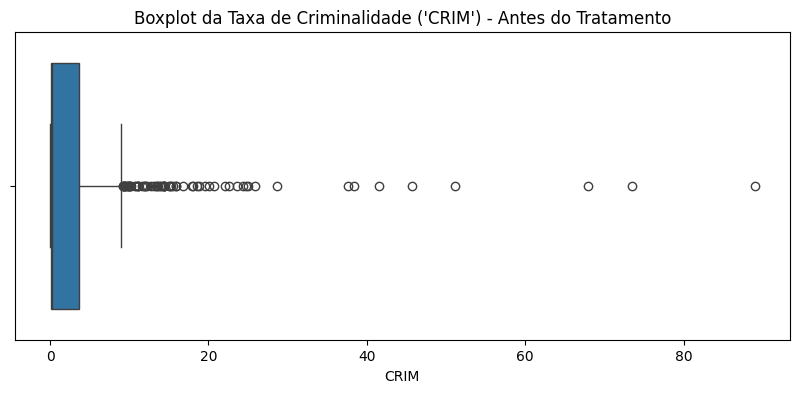

In [38]:
# 1. Identificação Visual com Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_boston['CRIM'])
plt.title("Boxplot da Taxa de Criminalidade ('CRIM') - Antes do Tratamento")
plt.show()

In [39]:
# 2. Identificação Estatística com IQR
Q1 = df_boston['CRIM'].quantile(0.25)
Q3 = df_boston['CRIM'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"\nLimite superior para outliers (Q3 + 1.5*IQR): {limite_superior:.4f}")
outliers_count = df_boston[df_boston['CRIM'] > limite_superior].shape[0]
print(f"Número de outliers encontrados: {outliers_count}")


Limite superior para outliers (Q3 + 1.5*IQR): 9.0696
Número de outliers encontrados: 66


In [40]:
# 3. Tratamento por Capping (Limitação)
# Valores acima do limite superior serão substituídos pelo próprio limite.
# np.where(condicao, valor_se_verdadeiro, valor_se_falso)
df_boston_capped = df_boston.copy()
df_boston_capped['CRIM'] = np.where(
    df_boston_capped['CRIM'] > limite_superior,
    limite_superior,
    df_boston_capped['CRIM']
)

print("\nDescrição da coluna 'CRIM' APÓS o tratamento:")
print(df_boston_capped['CRIM'].describe())


Descrição da coluna 'CRIM' APÓS o tratamento:
count    506.000000
mean       2.225032
std        3.313353
min        0.006320
25%        0.082045
50%        0.256510
75%        3.677083
max        9.069639
Name: CRIM, dtype: float64


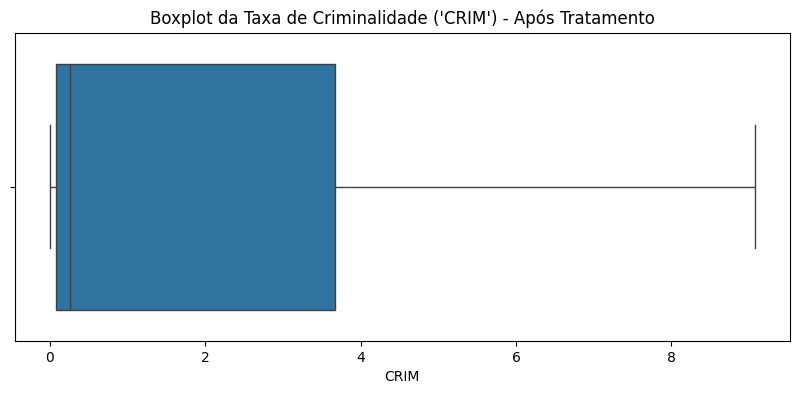

In [41]:
# Verificação visual pós-tratamento
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_boston_capped['CRIM'])
plt.title("Boxplot da Taxa de Criminalidade ('CRIM') - Após Tratamento")
plt.show()